# Práctica 2: Morphing Facial mediante el Algoritmo de Sinkhorn.

## 1. Introducción.

El objetivo de esta parte es hacer un *morphing* entre dos imágenes de las caras de Jordi y Jesús. Buscamos transportar físicamente la masa (los píxeles) de la cara 1 a la cara 2.

Para ello, utilizamos el Transporte Óptimo. Separamos cada imagen en los tres canales RGB y las tratamos como una distribución de probabilidad, donde la intensidad del píxel representa la cantidad de masa en esa posición.

### 1.1 El Problema Matemático
Lo que buscamos en este problema es la **Matriz de Transporte $\bold{P}$** ($N \times N$) que minimice el coste total de mover la distribución inicial $\bold{a}$ a la final $\bold{b}$, es decir, que nos diga cuánta masa mover de cada píxel $i$ de la imagen de origen a cada píxel $j$ de la imagen de destino, de la manera menos costosa posible.

El problema discreto de Kantorovich busca minimizar: 
$$\min_P \sum_{i,j} P_{ij} C_{ij}$$

El problema es que resolver esto mediante Programación Lineal con el método del Simplex tiene una complejidad cúbica $O(N^3 \log N)$, inviable para imágenes, que tienen una gran cantidad de píxeles.

Para hacerlo computacionalmente eficiente, usamos el **Algoritmo de Sinkhorn-Knopp**, que añade una penalización por entropía.

La fórmula usada es la **Regularización Entrópica del Transporte Óptimo**:
$$
\text{arg min}_{P \in \mathbb{R}_+^{n \times n}} \left( \sum_{i}\sum_{j} P_{ij}C_{ij} + \epsilon \sum_{i}\sum_{j} P_{ij} \ln(P_{ij}) \right)
$$

Donde:
* **$P_{ij}$**: Cantidad de masa que viaja del píxel $i$ al píxel $j$.
* **$C_{ij}$**: Es el coste de mover masa de $i$ a $j$. Nosotros usamos la distancia euclídea al cuadrado ($||x_i - x_j||^2$), lo que penaliza los movimientos largos/con mucha distancia.
* $\sum P \ln P$: Es el negativo de la entropía. Al minimizar esto, estamos maximizando la entropía, lo que "difumina" el transporte. 
* **$\epsilon$**: Es el parámetro de regularización. Controla el equilibrio entre precisión del transporte óptimo y borrosidad.

Esto convierte un problema computacionalmente muy difícil como lo es el método del símplex, en uno muy rápido (iterativo).

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tqdm import tqdm
from scipy.spatial.distance import cdist
%matplotlib inline

## 2. Preprocesamiento:

Para aplicar el algoritmo, no podemos usar las imágenes con las entradas tal cual como las leemos con cv2 (matrices de ints 0-255). Tenemos que convertirlas en vectores que representan distribuciones de probabilidad.

**Función ``processing``:**
1.  **Redimensión:** Reducimos la resolución de las imágenes porque el algoritmo de sinkhorn escala mal con muchos píxeles, ya que ocupa mucho en memoria y gasta mucha RAM. Por ejemplo, con imágenes en HD, la matriz de costes tendría billones de celdas y no cabrían en la RAM. 
2. **Casting de tipo a float32**: Porque el algoritmo de sinkhorn trata las imágenes como distribuciones de probabilidad. Al hacer las operaciones, necesitamos mucha precisión para dividir y multiplicar.
3.  **Aplanado:** Convertimos la matriz 2D en un vector 1D. Al algoritmo no le importa la forma de la cara, solo usa las imágenes como una lista de cantidades de masa en cada píxel.
4.  **Estabilidad sumando 1e-9:** Sumamos un valor muy pequeño para evitar que haya píxeles con valor 0 absoluto, lo que rompería las divisiones del algoritmo.
5.  **Normalización:** La suma total de la masa en ambas imágenes debe ser exactamente 1 al ser una distribución de probabilidad. Si no, el transporte no es válido, ya que sobraría o faltaría masa en una de las imágenes. Toda la masa de una imagen se tiene que transformar en masa de la otra, no se puede perder o crear nueva masa. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.spatial.distance import cdist
from tqdm import tqdm
    
class Morphing():
    def __init__(self, img1_path, img2_path, resolucion=128, epsilon=0.01, n_iter=1000, num_frames=10, color=True):
        # Cargamos las imágenes con OpenCV.
        self.img1 = cv2.imread(img1_path)
        self.img2 = cv2.imread(img2_path)
        
        # Convertimos la imagen de BGR a RGB  o grises para poder visualizarla bien en matplotlib.
        if color:
            self.img1 = cv2.cvtColor(self.img1, cv2.COLOR_BGR2RGB)
            self.img2 = cv2.cvtColor(self.img2, cv2.COLOR_BGR2RGB)
        else:
            self.img1 = cv2.cvtColor(self.img1, cv2.COLOR_BGR2GRAY)
            self.img2 = cv2.cvtColor(self.img2, cv2.COLOR_BGR2GRAY)

        self.shape = (resolucion, resolucion)
        self.epsilon = epsilon
        self.color = color

    def processing(self, img):
        '''Convierte imagen a distribución de probabilidad'''
        # Redimensionar
        img = cv2.resize(img, self.shape)
        # Convertir a float
        img = img.astype('float32')
        # Aplanar para pasarlo a vector 1D.
        img = img.flatten()
        # Evitar ceros y Normalizar para que sume 1.
        img += 1e-9
        img = img / img.sum()
        return img

## 3. Matriz de Costes y Kernel.

Estos parámetros van a definir de qué manera se va a realizar el morphing.

### Matriz de Costes $C$
Esto calcula qué tan cerca o lejos están los pares de píxeles. Sin esta matriz, no sabría si el pixel (0,0) de una imagen está cerca del pixel (0,1) o lejos. Utilizamos la métrica de la distancia euclídea al cuadrado.

- **Función `make_costs_matrix`:** Usamos `cdist` con `metric='sqeuclidean'` para calcular la distancia al cuadrado entre todas las coordenadas.

- Normalizamos $C$ dividiendo por el máximo para que los valores estén entre 0 y 1.

### Kernel de Gibbs $K$
La solución matemática al problema de minimización con entropía nos dice que la matriz de transporte tiene la forma $$P = \text{diag}(u) K \text{diag}(v)$$ donde $K$ es un núcleo gaussiano que se calcula con la matriz de costes:

$$K_{ij} = e^{-\frac{C_{ij}}{\epsilon}}$$

* **Función `get_kernel`:** Calculamos `np.exp(-costs_matrix / self.epsilon)`.
* Si $\epsilon$ es pequeño, $K$ solo conecta píxeles muy cercanos y el morphing será más nítido, pero la convergencia es más lenta. Si es grande, K se hace más difuso conectando píxeles lejanos, por lo que el morphing se verá más borroso.

In [4]:
def make_costs_matrix(self):    
        '''Genera la matriz de costes entre todos los pares de píxeles'''
        # Generamos un grid de coordenadas (x,y).
        x = np.arange(self.shape[0])
        X, Y = np.meshgrid(x, x)
        
        # Lista de coordenadas: [[0,0], [0,1], ... [N,N]]
        # Stack nos permite tener un array de (N_pixels, 2)
        coordenadas = np.stack([Y.ravel(), X.ravel()], axis=1)
        
        #La función cdist de scipy calcula la distancia entre todos los pares de puntos.
        # Devuelve una matriz N^2 x N^2
        costs_matrix = cdist(coordenadas, coordenadas, metric='sqeuclidean')
        costs_matrix = costs_matrix / costs_matrix.max()

        return costs_matrix, coordenadas

def get_kernel(self, costs_matrix):
        '''Calcula el Kernel K = exp(-C/epsilon)'''
        return np.exp(-costs_matrix / self.epsilon)

## 4. Algoritmo de Sinkhorn-Knopp 

Este es el algoritmo que resuelve el problema de minimización.

Para encontrar la matriz óptima $P$, necesitamos encontrar dos vectores de escalado $u$ y $v$ tales que las filas sumen la imagen 1 ($a$) y las columnas sumen la imagen 2 ($b$).

El algoritmo es un método que iteramos hasta converger:

-  $u \leftarrow \frac{a}{K \cdot v}$
-  $v \leftarrow \frac{b}{K^T \cdot u}$

**Función `sinkhorn`:**
* Implementamos el bucle.
* Al final, reconstruimos la Matriz de Transporte $P$:
    $$P_{ij} = u_i K_{ij} v_j$$

In [5]:
def sinkhorn(self, img1, img2, K, n_iter=100):
        '''Iteraciones de Sinkhorn para hallar P'''
        # Obtenemos distribuciones a y b
        a = self.processing(img1)
        b = self.processing(img2)
        
        # Inicializamos vectores de escalado
        u = np.ones(len(a))
        v = np.ones(len(b))

        for i in tqdm(range(n_iter), desc="Iteraciones Sinkhorn"):
            u = a / np.dot(K, v)
            v = b / np.dot(K.T, u)
        
        # Reconstrucción de la matriz P
        P = u[:, np.newaxis] * K * v[np.newaxis, :]
        return P

## 5. Generación de vídeo con interpolación de desplazamiento.

Una vez tenemos el mapa de transporte $P$, que nos dice cuánta masa va de i a j, generamos los frames intermedios para hacer el vídeo del morphing.

Para un tiempo $t \in [0, 1]$, movemos la masa según:
$$\text{pos}(t) = (1-t) \cdot \text{pos}_{\text{origen}} + t \cdot \text{pos}_{\text{destino}}$$

**Función `make_video`:**
Optimizamos el bucle con `np.where(P > threshold)` para procesar solo los pares de píxeles que transportan una cantidad significativa de masa.
También usamos `np.bincount` para sumar la masa que cae en el mismo píxel más rápidamente.

In [6]:
def make_video(self, P, coordenadas, num_frames=60):
    frames = []
    t_values = np.linspace(0, 1, num_frames)
    
    # Filtrado de transportes significativos (Optimización)
    threshold = 1e-10
    i_indices, j_indices = np.where(P > threshold)
    masas = P[i_indices, j_indices]
    
    coords_origen = coordenadas[i_indices]
    coords_destino = coordenadas[j_indices]
    
    for t in tqdm(t_values, desc="Generando frames"):
        # Interpolación lineal de posiciones
        pos_intermedias = (1 - t) * coords_origen + t * coords_destino
        
        # Discretización a coordenadas enteras
        py = np.clip(np.round(pos_intermedias[:, 0]).astype(int), 0, self.shape[0] - 1)
        px = np.clip(np.round(pos_intermedias[:, 1]).astype(int), 0, self.shape[1] - 1)
        
        indices = py * self.shape[1] + px
        
        # Acumulación rápida de masa
        frame = np.bincount(indices, weights=masas, minlength=self.shape[0] * self.shape[1])
        frame = frame.reshape(self.shape)
        
        # Normalización para visualización (evitando parpadeo extremo)
        frame = (frame / frame.max() * 255).astype(np.uint8)
        frames.append(frame)
    
    return frames

def save_video(self, frames, output_path='morphing.mp4', fps=30):
    height, width = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height), isColor=self.color)
    for frame in frames:
        out.write(frame)
    out.release()
    print(f"Video guardado en {output_path}")

def run(self, img1, img2, n_iter=100, num_frames=60):
    costs_matrix, coordenadas = self.make_costs_matrix()
    K = self.get_kernel(costs_matrix)
    P = self.sinkhorn(img1, img2, K, n_iter)
    frames = self.make_video(P, coordenadas, num_frames)
    return frames

def run_color(self, n_iter=100, num_frames=60):
    # Separar canales RGB
    R1, G1, B1 = self.img1[:,:,0], self.img1[:,:,1], self.img1[:,:,2]
    R2, G2, B2 = self.img2[:,:,0], self.img2[:,:,1], self.img2[:,:,2]

    imgs_channels = [[R1, R2], [G1, G2], [B1, B2]]
    frames_channels = []

    # Procesar cada canal independientemente
    for c1, c2 in imgs_channels:
        frames_channels.append(self.run(c1, c2, n_iter, num_frames))

    # Combinar canales y convertir a BGR para guardar
    frames_finales = []
    for f in range(num_frames):
        rgb_frame = np.stack([frames_channels[0][f], frames_channels[1][f], frames_channels[2][f]], axis=2)
        bgr_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2BGR)
        frames_finales.append(bgr_frame)

    return frames_finales

# Añadir los métodos a la clase Morphing
Morphing.make_costs_matrix = make_costs_matrix
Morphing.get_kernel = get_kernel
Morphing.sinkhorn = sinkhorn
Morphing.make_video = make_video
Morphing.save_video = save_video
Morphing.run = run
Morphing.run_color = run_color

Generando frames: 100%|██████████| 200/200 [00:56<00:00,  3.51it/s]


Video guardado en morphing_final.mp4


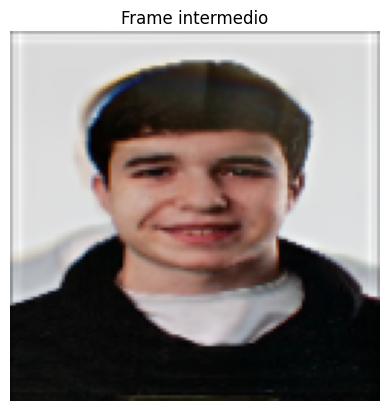

In [ ]:

morphing = Morphing('caras/jesus.jpeg','caras/jordi.jpeg', resolucion= 128, epsilon= 0.0005, n_iter= 600)

frames = morphing.run_color(num_frames= 200, n_iter= 600)

morphing.save_video(frames, output_path= 'morphing.mp4')

plt.imshow(cv2.cvtColor(frames[30], cv2.COLOR_BGR2RGB))
plt.title("Frame intermedio")
plt.axis('off')
plt.show()